In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import cv2

input_folder = "/kaggle/input/datasets/dhriti1015/ohrc-data/onlypng"  # change this
output_folder = "/kaggle/working/tiles"

os.makedirs(output_folder, exist_ok=True)

In [2]:
tile_size = 512
overlap = 0.25
stride = int(tile_size * (1 - overlap))

tile_count = 0

for img_name in os.listdir(input_folder):
    img_path = os.path.join(input_folder, img_name)
    img = cv2.imread(img_path)

    if img is None:
        continue

    h, w, _ = img.shape

    for y in range(0, h - tile_size + 1, stride):
        for x in range(0, w - tile_size + 1, stride):
            
            tile = img[y:y+tile_size, x:x+tile_size]

            tile_name = f"{img_name.split('.')[0]}_{tile_count}.jpg"
            cv2.imwrite(os.path.join(output_folder, tile_name), tile)

            tile_count += 1

print("Total tiles created:", tile_count)

Total tiles created: 898


In [3]:
import os

tiles_folder = "/kaggle/working/tiles"

deleted_count = 0

for file in os.listdir(tiles_folder):
    if "149733" in file:
        os.remove(os.path.join(tiles_folder, file))
        deleted_count += 1

print("Deleted files:", deleted_count)

Deleted files: 48


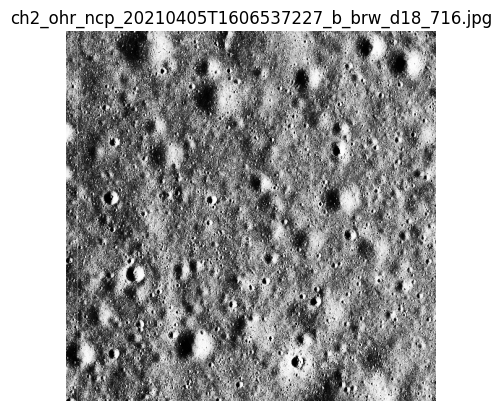

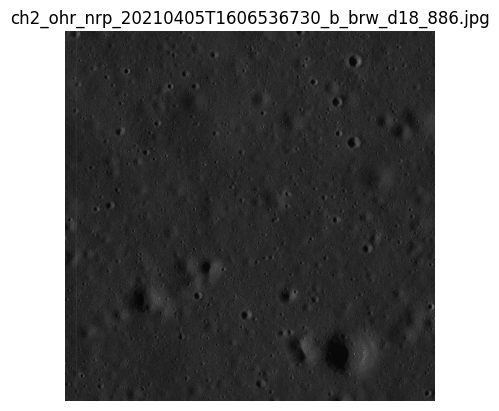

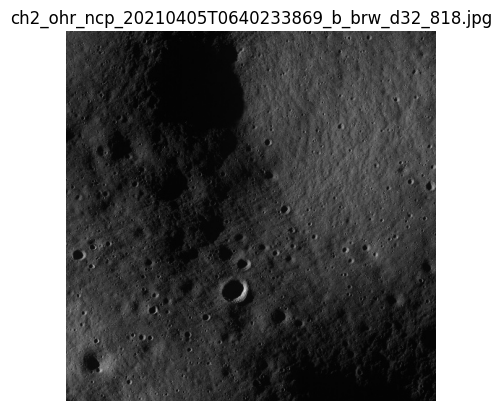

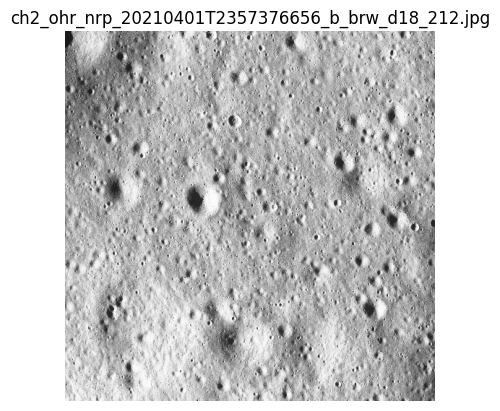

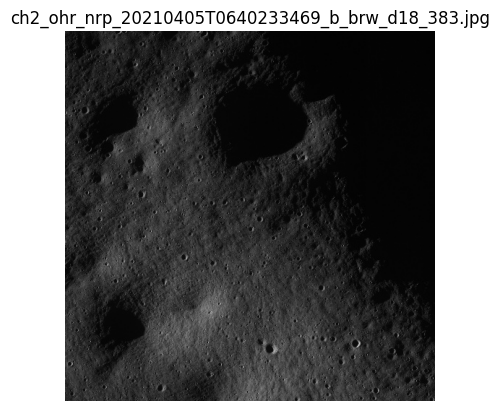

In [4]:
import matplotlib.pyplot as plt

tile_files = os.listdir(output_folder)

for img_name in tile_files[:5]:
    img = cv2.imread(os.path.join(output_folder, img_name))
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')
    plt.show()

In [5]:
import os
import cv2

input_folder = "/kaggle/working/tiles"
output_folder = "/kaggle/working/processed_tiles"

os.makedirs(output_folder, exist_ok=True)

In [6]:
count = 0

for img_name in os.listdir(input_folder):
    img_path = os.path.join(input_folder, img_name)
    img = cv2.imread(img_path)

    if img is None:
        continue

    # ✅ Resize to 640x640 (PDF requirement)
    img = cv2.resize(img, (640, 640))

    # ✅ Optional: contrast enhancement (helps crater visibility)
    img = cv2.convertScaleAbs(img, alpha=1.2, beta=10)

    cv2.imwrite(os.path.join(output_folder, img_name), img)
    count += 1

print("Processed images:", count)

Processed images: 850


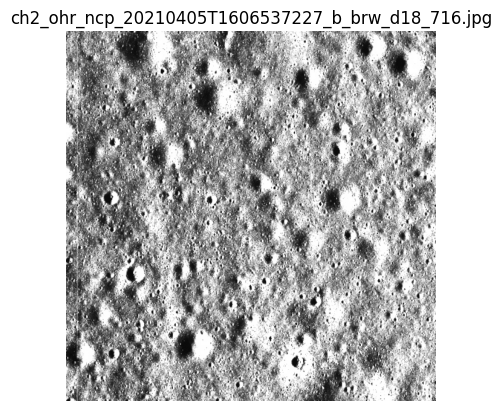

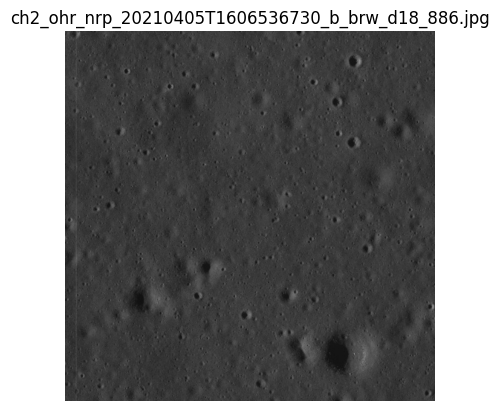

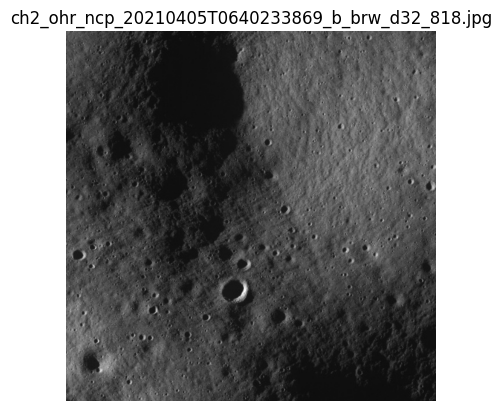

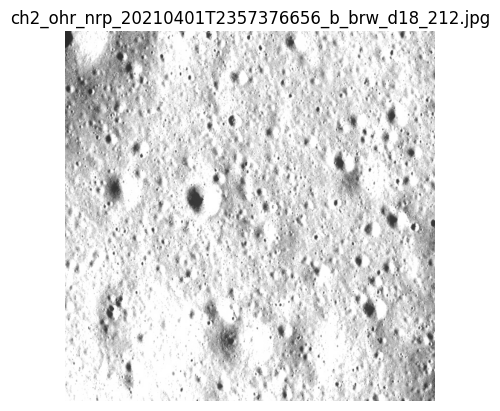

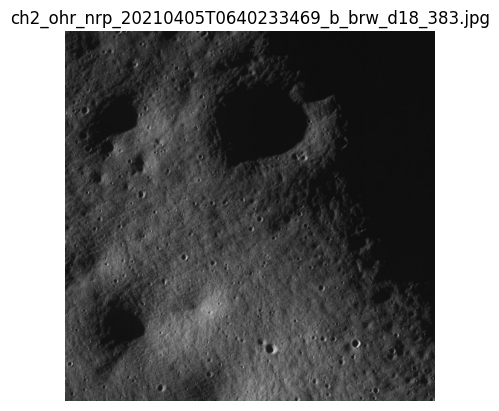

In [7]:
import matplotlib.pyplot as plt

files = os.listdir(output_folder)

for img_name in files[:5]:
    img = cv2.imread(os.path.join(output_folder, img_name))
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')
    plt.show()

In [8]:
import shutil

folder = "/kaggle/working/processed_tiles"

if os.path.exists(folder):
    shutil.rmtree(folder)

print("Old processed_tiles deleted")

Old processed_tiles deleted


In [11]:
import os
import cv2
import random

input_folder = "/kaggle/working/tiles"
output_folder = "/kaggle/working/processed_tiles"

os.makedirs(output_folder, exist_ok=True)

In [12]:
count = 0

for img_name in os.listdir(input_folder):
    img_path = os.path.join(input_folder, img_name)
    img = cv2.imread(img_path)

    if img is None:
        continue

    # ✅ Resize (PDF requirement)
    img = cv2.resize(img, (640, 640))

    # ✅ Random contrast & brightness
    alpha = random.uniform(0.9, 1.3)   # contrast
    beta = random.randint(-10, 10)     # brightness

    img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

    cv2.imwrite(os.path.join(output_folder, img_name), img)
    count += 1

print("Processed images:", count)

Processed images: 850


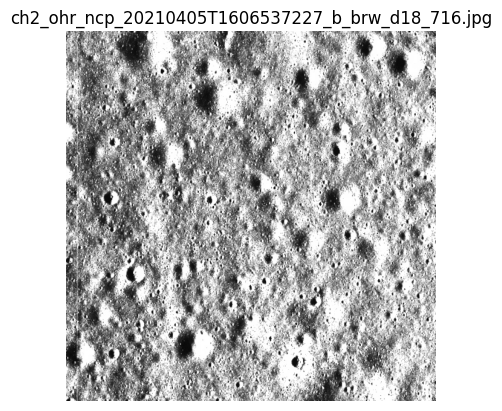

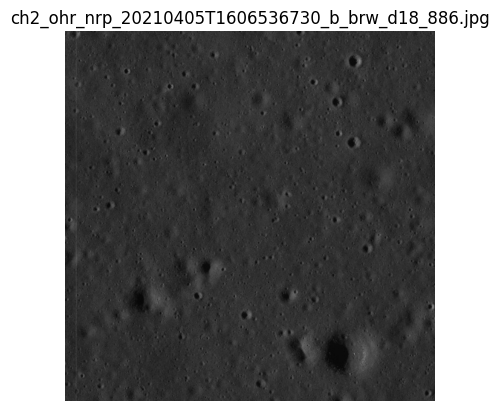

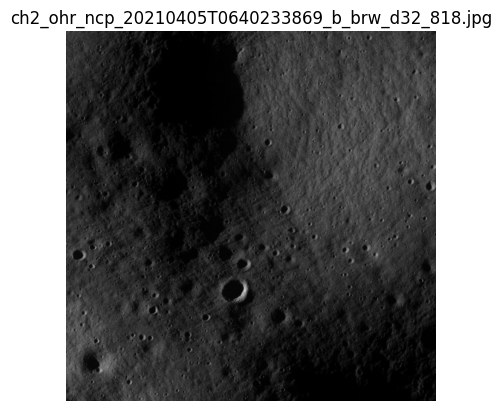

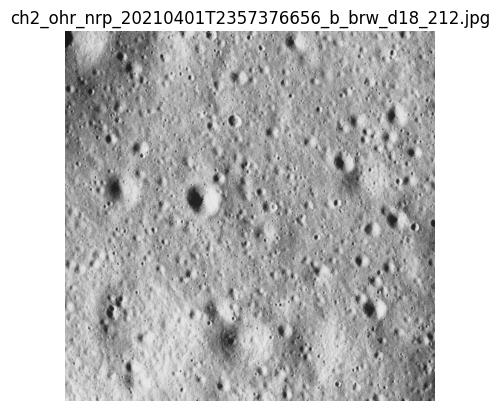

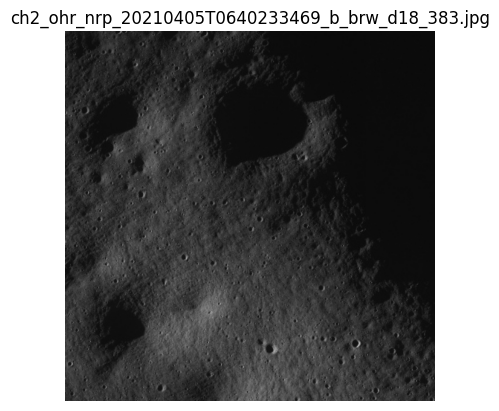

In [13]:
import matplotlib.pyplot as plt

files = os.listdir(output_folder)

for img_name in files[:5]:
    img = cv2.imread(os.path.join(output_folder, img_name))
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')
    plt.show()

In [14]:
import shutil

shutil.make_archive(
    "/kaggle/working/processed_tiles",
    'zip',
    "/kaggle/working/processed_tiles"
)

print("Zipped successfully")

Zipped successfully


In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.9 MB/s eta 0:00:0000:01


In [4]:
from ultralytics import YOLO

# Load your trained model
model = YOLO("/kaggle/input/models/dhriti1015/labellingtrial/other/default/1/best.pt")  # or the full path to your weights

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
results = model.predict(source="/kaggle/input/datasets/dhriti1015/123456/ch2_ohr_ncp_20210405T0047199117_b_brw_d32_44.jpg", conf=0.15)


image 1/1 /kaggle/input/datasets/dhriti1015/123456/ch2_ohr_ncp_20210405T0047199117_b_brw_d32_44.jpg: 640x640 7 crater_smalls, 1 crater_medium, 6 crater_larges, 301.6ms
Speed: 7.4ms preprocess, 301.6ms inference, 21.5ms postprocess per image at shape (1, 3, 640, 640)


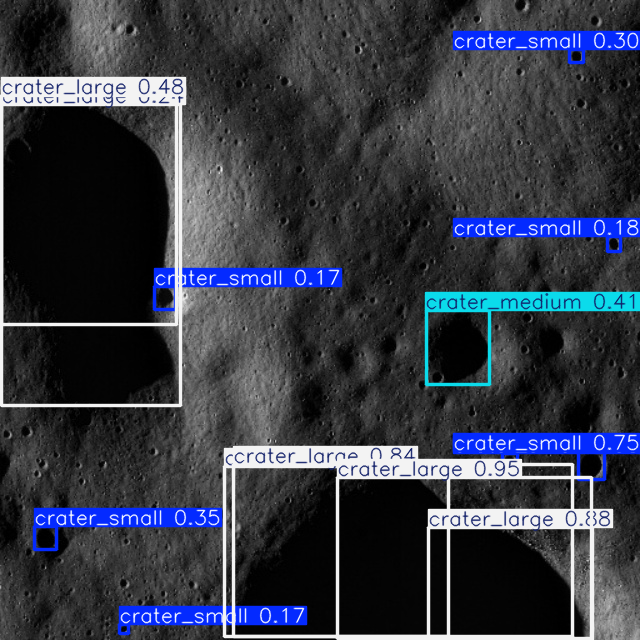

In [6]:
results[0].show()

In [ ]:
from pathlib import Path

base = Path("/kaggle/working/split_40")

(batch1 := base / "batch_1").mkdir(parents=True, exist_ok=True)
(batch2 := base / "batch_2").mkdir(parents=True, exist_ok=True)

print("✅ Folders created")